# 06 — Métricas de Clasificación del Sistema de Detección (Punto 5)

**Objetivo:** Calcular métricas estándar de clasificación binaria para evaluar el desempeño del sistema ICD+AG.

**Métricas calculadas por severidad, tipo de elemento y zona:**

| Métrica | Fórmula | Interpretación |
|---------|---------|----------------|
| **Precision** | TP / (TP + FP) | ¿Cuántas alarmas son reales? |
| **Recall (TPR)** | TP / (TP + FN) | ¿Cuántos daños reales son detectados? |
| **F1-score** | 2 × P×R / (P+R) | Balance entre precisión y cobertura |
| **FPR** | FP / (FP + TN) | Tasa de falsas alarmas |

**Definición operativa por corrida:**
- **TP** = `DeteccionOK_binario == 1` — el AG detectó el elemento dañado
- **FP** = `N_FalsosPositivos` — elementos intactos incorrectamente marcados como dañados
- **FN** = `DeteccionOK_binario == 0` — elemento dañado no detectado
- **TN** = (N_elementos_total - 1) - N_FalsosPositivos — correctamente no detectados

**Corridas:** 1,080 (abolladura) + 2,160 (corrosión) = 3,240 total

**Punto 5 de los 6 mínimos para AOR:**  
> *Métricas tipo: tasa de verdaderos positivos / falsos positivos, no solo curvas ICD.*

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# --- Estilo consistente con notebooks anteriores ---
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 12,
    'legend.fontsize': 10,
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
})
sns.set_palette('husl')
%matplotlib inline

print('✓ Librerías cargadas')

✓ Librerías cargadas


## 1. Configuración de Rutas

In [2]:
base_path = Path.home() / 'github' / 'Proyecto-doctoral'
resultados_nuevos = base_path / 'outputs' / 'resultados_nuevos'

paths = {
    'abolladura': {
        'xlsx': resultados_nuevos / 'abolladuras_2026' / 'todos_los_resultados_con_ICD_abolladura.xlsx',
        'out_dir': resultados_nuevos / 'abolladuras_2026',
        'pct_max': 45,
        'label_es': 'Abolladura',
        'label_en': 'Denting',
        'color': '#E74C3C',
    },
    'corrosion': {
        'xlsx': resultados_nuevos / 'corrosion_2026' / 'todos_los_resultados_con_ICD_corrosion.xlsx',
        'out_dir': resultados_nuevos / 'corrosion_2026',
        'pct_max': 90,
        'label_es': 'Corrosión',
        'label_en': 'Corrosion',
        'color': '#2980B9',
    },
}

# Número total de elementos del modelo (para calcular TN)
# Valor constante del modelo de plataforma jacket del estudio
N_ELEMENTOS_TOTAL = None  # Se detecta automáticamente del número de elementos únicos

for tipo, cfg in paths.items():
    existe = cfg['xlsx'].exists()
    print(f"{'✓' if existe else '✗'} {tipo:12s}: {cfg['xlsx'].name}")

print()
print('Salidas: abolladuras_2026/ y corrosion_2026/')

✓ abolladura  : todos_los_resultados_con_ICD_abolladura.xlsx
✓ corrosion   : todos_los_resultados_con_ICD_corrosion.xlsx

Salidas: abolladuras_2026/ y corrosion_2026/


## 2. Carga y Validación de Datos

In [3]:
dfs = {}

for tipo, cfg in paths.items():
    df = pd.read_excel(cfg['xlsx'])
    
    # Verificar columnas requeridas
    cols_requeridas = ['ID', 'Elemento', 'Porcentaje', 'DeteccionOK',
                       'N_FalsosPositivos', 'ICD', 'Tipo_elemento_a_buscar', 'DeteccionOK_binario']
    faltantes = [c for c in cols_requeridas if c not in df.columns]
    if faltantes:
        raise ValueError(f'[{tipo}] Columnas faltantes: {faltantes}')
    
    # Agregar columna de tipo de daño
    df['damage_type'] = cfg['label_en']
    dfs[tipo] = df
    
    n_elementos = df['Elemento'].nunique()
    porcentajes = sorted(df['Porcentaje'].unique())
    tipos_elem = df['Tipo_elemento_a_buscar'].unique()
    
    print(f'=== {cfg["label_en"].upper()} ===')
    print(f'  Corridas totales    : {len(df):,}')
    print(f'  Elementos únicos    : {n_elementos}')
    print(f'  Severidades [%]     : {porcentajes}')
    print(f'  Tipos de elemento   : {list(tipos_elem)}')
    print(f'  DeteccionOK valores : {sorted(df["DeteccionOK"].unique())}')
    print(f'  FP max              : {df["N_FalsosPositivos"].max()}')
    print(f'  FP mean             : {df["N_FalsosPositivos"].mean():.2f}')
    print()

=== DENTING ===
  Corridas totales    : 1,080
  Elementos únicos    : 120
  Severidades [%]     : [5, 10, 15, 20, 25, 30, 35, 40, 45]
  Tipos de elemento   : ['Inclined_leg', 'Brace', 'Beam']
  DeteccionOK valores : [0.0, 0.5, 1.0]
  FP max              : 30
  FP mean             : 3.49

=== CORROSION ===
  Corridas totales    : 2,160
  Elementos únicos    : 120
  Severidades [%]     : [5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80, 85, 90]
  Tipos de elemento   : ['Inclined_leg', 'Brace', 'Beam']
  DeteccionOK valores : [0.0, 0.5, 1.0]
  FP max              : 30
  FP mean             : 2.80



## 3. Cálculo de Métricas por Corrida

Para cada corrida individual se derivan los 4 componentes de la matriz de confusión y luego las métricas agregadas.

In [4]:
def calcular_metricas_por_corrida(df, n_elem_total):
    """
    Calcula TP, FP, FN, TN y métricas derivadas para cada fila (corrida).
    
    Modelo operativo:
    - Cada corrida tiene exactamente 1 elemento dañado (ground truth positivo).
    - N_FalsosPositivos = elementos intactos incorrectamente marcados por el AG.
    - DeteccionOK_binario = 1 si el AG identificó el elemento dañado real.
    """
    result = df.copy()
    
    # --- Componentes de la matriz de confusión ---
    result['TP'] = result['DeteccionOK_binario'].astype(int)          # 1 si detectó bien, 0 si no
    result['FP'] = result['N_FalsosPositivos'].astype(int)            # alarmas falsas
    result['FN'] = 1 - result['TP']                                    # fallo en detectar el dañado
    result['TN'] = (n_elem_total - 1) - result['FP']                  # correctamente no detectados
    result['TN'] = result['TN'].clip(lower=0)                          # evitar negativos por casos extremos
    
    # --- Precision (por corrida) ---
    denom_precision = result['TP'] + result['FP']
    result['Precision'] = np.where(
        denom_precision > 0,
        result['TP'] / denom_precision,
        0.0  # Si no detectó nada, precisión = 0
    )
    
    # --- Recall = TP / (TP + FN) = TP (binario: 1 positivo real por corrida) ---
    result['Recall'] = result['TP'].astype(float)  # = 1.0 o 0.0
    
    # --- F1-score ---
    denom_f1 = result['Precision'] + result['Recall']
    result['F1'] = np.where(
        denom_f1 > 0,
        2 * result['Precision'] * result['Recall'] / denom_f1,
        0.0
    )
    
    # --- FPR: False Positive Rate = FP / (FP + TN) ---
    denom_fpr = result['FP'] + result['TN']
    result['FPR'] = np.where(
        denom_fpr > 0,
        result['FP'] / denom_fpr,
        0.0
    )
    
    return result


# Calcular para ambos tipos de daño
dfs_metricas = {}

for tipo, df in dfs.items():
    n_elem = df['Elemento'].nunique()
    df_m = calcular_metricas_por_corrida(df, n_elem)
    dfs_metricas[tipo] = df_m
    
    print(f'=== {tipo.upper()} (N_elementos = {n_elem}) ===')
    print(f'  TP total  : {df_m["TP"].sum():,}')
    print(f'  FP total  : {df_m["FP"].sum():,}')
    print(f'  FN total  : {df_m["FN"].sum():,}')
    print(f'  TN total  : {df_m["TN"].sum():,}')
    print(f'  Precision media : {df_m["Precision"].mean():.3f}')
    print(f'  Recall media    : {df_m["Recall"].mean():.3f}')
    print(f'  F1 media        : {df_m["F1"].mean():.3f}')
    print(f'  FPR media       : {df_m["FPR"].mean():.4f}')
    print()

=== ABOLLADURA (N_elementos = 120) ===
  TP total  : 996
  FP total  : 3,766
  FN total  : 84
  TN total  : 124,754
  Precision media : 0.477
  Recall media    : 0.922
  F1 media        : 0.585
  FPR media       : 0.0293

=== CORROSION (N_elementos = 120) ===
  TP total  : 2,084
  FP total  : 6,051
  FN total  : 76
  TN total  : 250,989
  Precision media : 0.512
  Recall media    : 0.965
  F1 media        : 0.629
  FPR media       : 0.0235



## 4. Métricas Agregadas por Severidad y Tipo de Elemento

In [5]:
def agregar_metricas(df_m, groupby_cols):
    """
    Agrega métricas por grupo.
    Calcula Precision/Recall/F1 tanto por media de corridas como por suma de TP/FP/FN.
    """
    agg = df_m.groupby(groupby_cols).agg(
        N_corridas=('TP', 'count'),
        TP_sum=('TP', 'sum'),
        FP_sum=('FP', 'sum'),
        FN_sum=('FN', 'sum'),
        TN_sum=('TN', 'sum'),
        Precision_mean=('Precision', 'mean'),
        Recall_mean=('Recall', 'mean'),
        F1_mean=('F1', 'mean'),
        FPR_mean=('FPR', 'mean'),
        ICD_mean=('ICD', 'mean'),
        ICD_std=('ICD', 'std'),
    ).reset_index()
    
    # Métricas macro (por suma acumulada) — más robustas para datasets desbalanceados
    denom_p = agg['TP_sum'] + agg['FP_sum']
    agg['Precision_macro'] = np.where(denom_p > 0, agg['TP_sum'] / denom_p, 0.0)
    agg['Recall_macro'] = agg['TP_sum'] / (agg['TP_sum'] + agg['FN_sum'])
    denom_f1 = agg['Precision_macro'] + agg['Recall_macro']
    agg['F1_macro'] = np.where(denom_f1 > 0,
                               2 * agg['Precision_macro'] * agg['Recall_macro'] / denom_f1,
                               0.0)
    return agg


tablas = {}
for tipo, df_m in dfs_metricas.items():
    tablas[tipo] = agregar_metricas(df_m, ['Porcentaje', 'Tipo_elemento_a_buscar'])

print('Tabla abolladura (primeras filas):')
cols_display = ['Porcentaje', 'Tipo_elemento_a_buscar', 'N_corridas',
                'TP_sum', 'FP_sum', 'FN_sum', 'Precision_macro', 'Recall_macro', 'F1_macro']
print(tablas['abolladura'][cols_display].head(12).to_string(index=False))

Tabla abolladura (primeras filas):
 Porcentaje Tipo_elemento_a_buscar  N_corridas  TP_sum  FP_sum  FN_sum  Precision_macro  Recall_macro  F1_macro
          5                   Beam          16      16     180       0         0.081633      1.000000  0.150943
          5                  Brace          84      74     113      10         0.395722      0.880952  0.546125
          5           Inclined_leg          20      15      91       5         0.141509      0.750000  0.238095
         10                   Beam          16      16     174       0         0.084211      1.000000  0.155340
         10                  Brace          84      80     118       4         0.404040      0.952381  0.567376
         10           Inclined_leg          20      12      67       8         0.151899      0.600000  0.242424
         15                   Beam          16      16     170       0         0.086022      1.000000  0.158416
         15                  Brace          84      80     116       

## 5. Figura 1 — Precision, Recall y F1 vs Severidad (por tipo de elemento)

Figura publicable en inglés, 300 DPI para AOR.

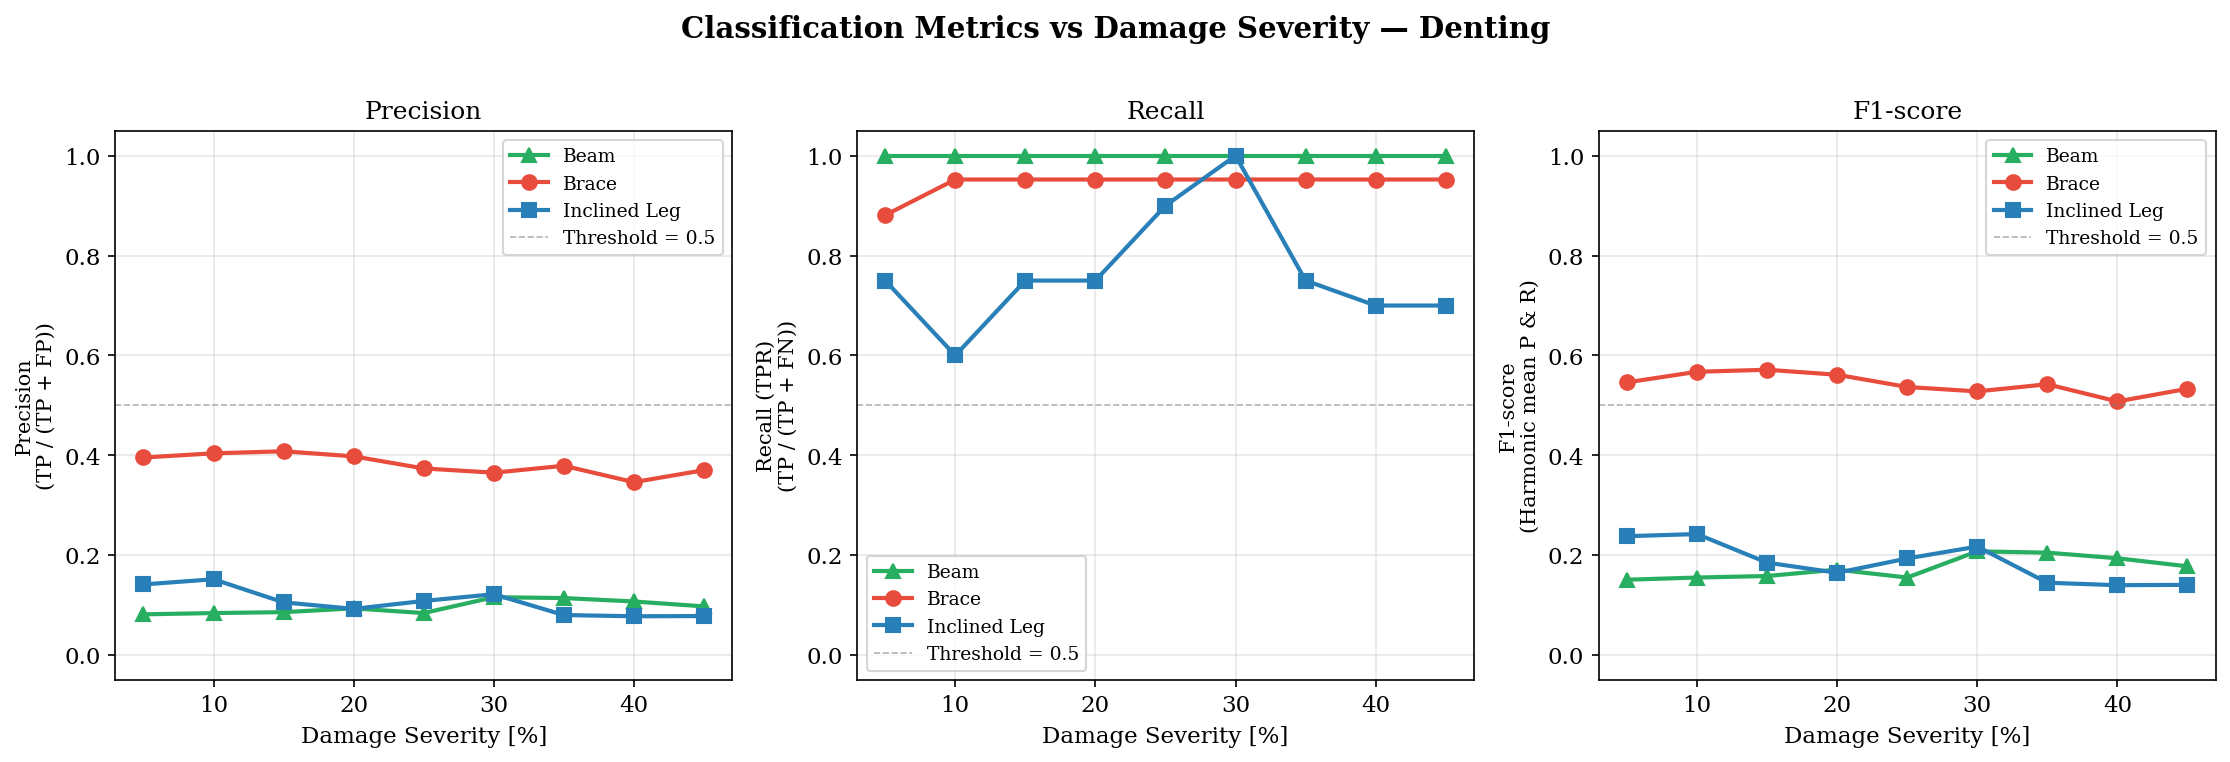

✓ Guardado: /home/fcisnerosr/github/Proyecto-doctoral/outputs/resultados_nuevos/abolladuras_2026/precision_recall_F1_denting.png


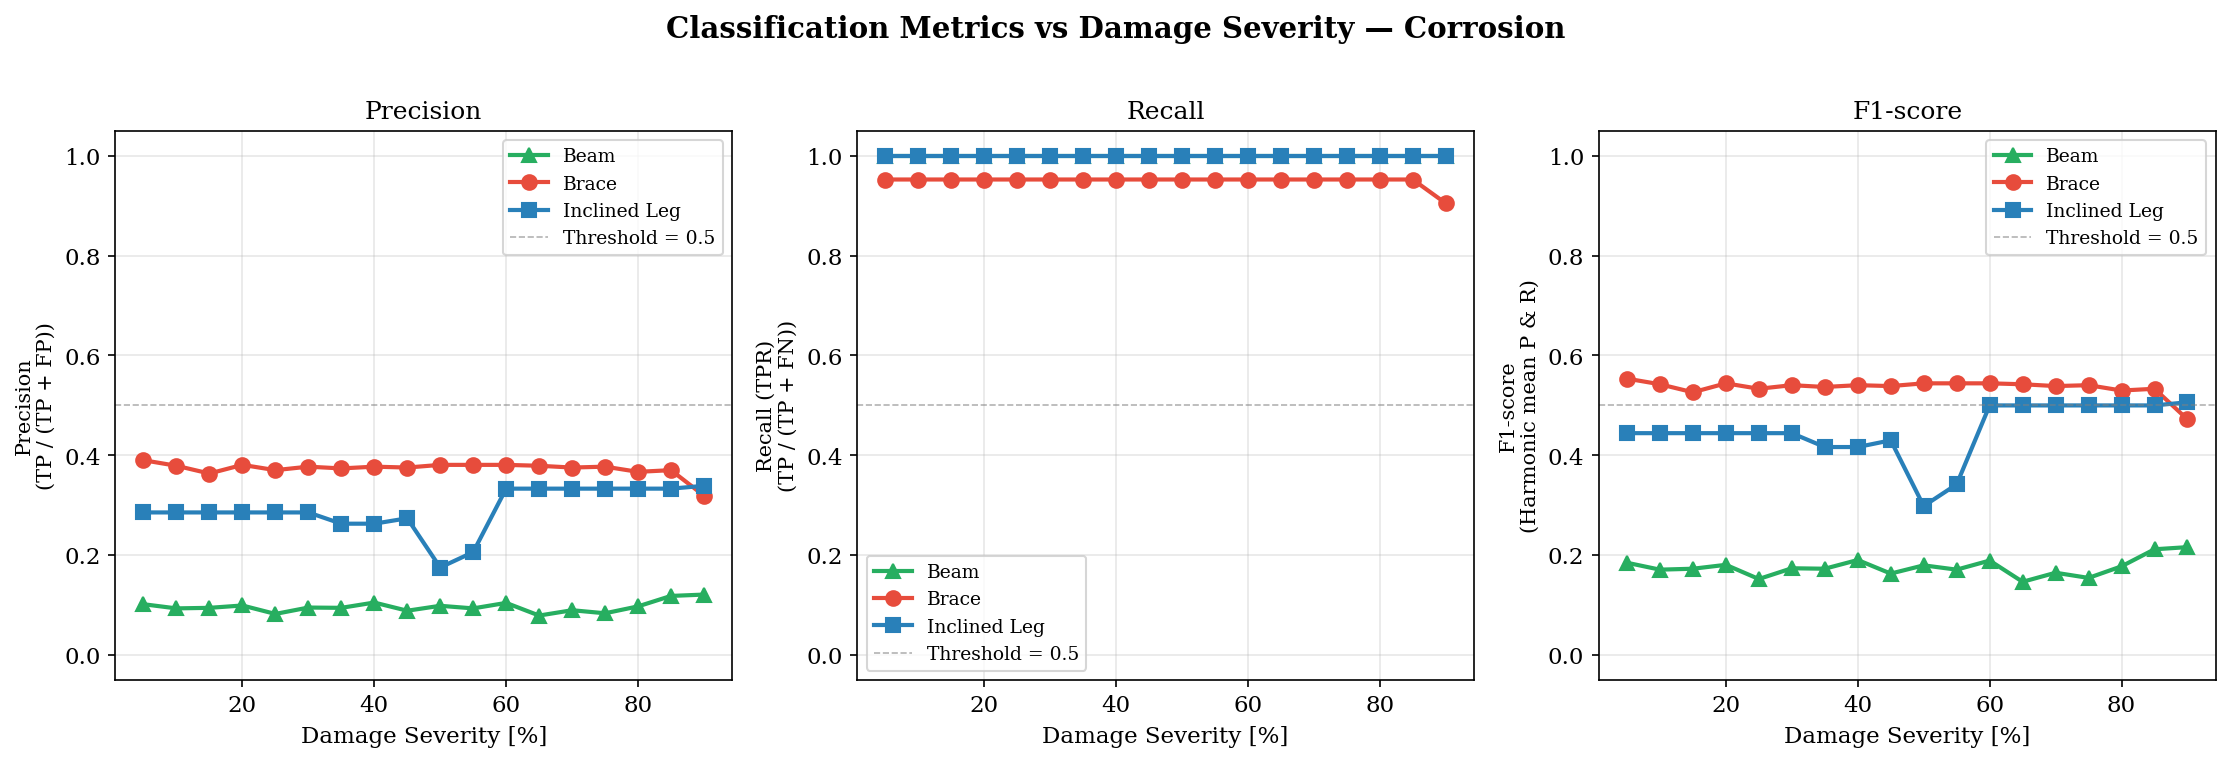

✓ Guardado: /home/fcisnerosr/github/Proyecto-doctoral/outputs/resultados_nuevos/corrosion_2026/precision_recall_F1_corrosion.png


In [6]:
ELEM_COLORS = {
    'Brace':       '#E74C3C',
    'Inclined_leg': '#2980B9',
    'Beam':        '#27AE60',
}
ELEM_MARKERS = {
    'Brace':       'o',
    'Inclined_leg': 's',
    'Beam':        '^',
}
ELEM_LABELS = {
    'Brace':       'Brace',
    'Inclined_leg': 'Inclined Leg',
    'Beam':        'Beam',
}


def plot_metricas_vs_severidad(tabla, tipo_dano_en, tipo_dano_es, out_dir, cfg_color):
    fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=False)
    fig.suptitle(f'Classification Metrics vs Damage Severity — {tipo_dano_en}',
                 fontsize=14, fontweight='bold', y=1.01)

    metricas = [
        ('Precision_macro', 'Precision', 'Precision\n(TP / (TP + FP))'),
        ('Recall_macro',    'Recall',    'Recall (TPR)\n(TP / (TP + FN))'),
        ('F1_macro',        'F1-score',  'F1-score\n(Harmonic mean P & R)'),
    ]

    for ax, (col, titulo, ylabel) in zip(axes, metricas):
        for elem in tabla['Tipo_elemento_a_buscar'].unique():
            sub = tabla[tabla['Tipo_elemento_a_buscar'] == elem].sort_values('Porcentaje')
            ax.plot(
                sub['Porcentaje'], sub[col],
                marker=ELEM_MARKERS.get(elem, 'o'),
                color=ELEM_COLORS.get(elem, 'gray'),
                linewidth=2, markersize=7,
                label=ELEM_LABELS.get(elem, elem)
            )
        ax.set_xlabel('Damage Severity [%]', fontsize=11)
        ax.set_ylabel(ylabel, fontsize=10)
        ax.set_title(titulo, fontsize=12)
        ax.set_ylim(-0.05, 1.05)
        ax.axhline(0.5, color='gray', linestyle='--', linewidth=0.8, alpha=0.6, label='Threshold = 0.5')
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    fname = out_dir / f'precision_recall_F1_{tipo_dano_es.lower()}.png'
    plt.savefig(fname, dpi=300)
    plt.show()
    print(f'✓ Guardado: {fname}')
    return fname


for tipo in ['abolladura', 'corrosion']:
    cfg = paths[tipo]
    plot_metricas_vs_severidad(
        tablas[tipo],
        tipo_dano_en=cfg['label_en'],
        tipo_dano_es=cfg['label_en'],
        out_dir=cfg['out_dir'],
        cfg_color=cfg['color']
    )

## 6. Figura 2 — Comparación lado a lado: Abolladura vs Corrosión (F1-score)

Figura comparativa única para insertar en la Sección de Resultados del paper.

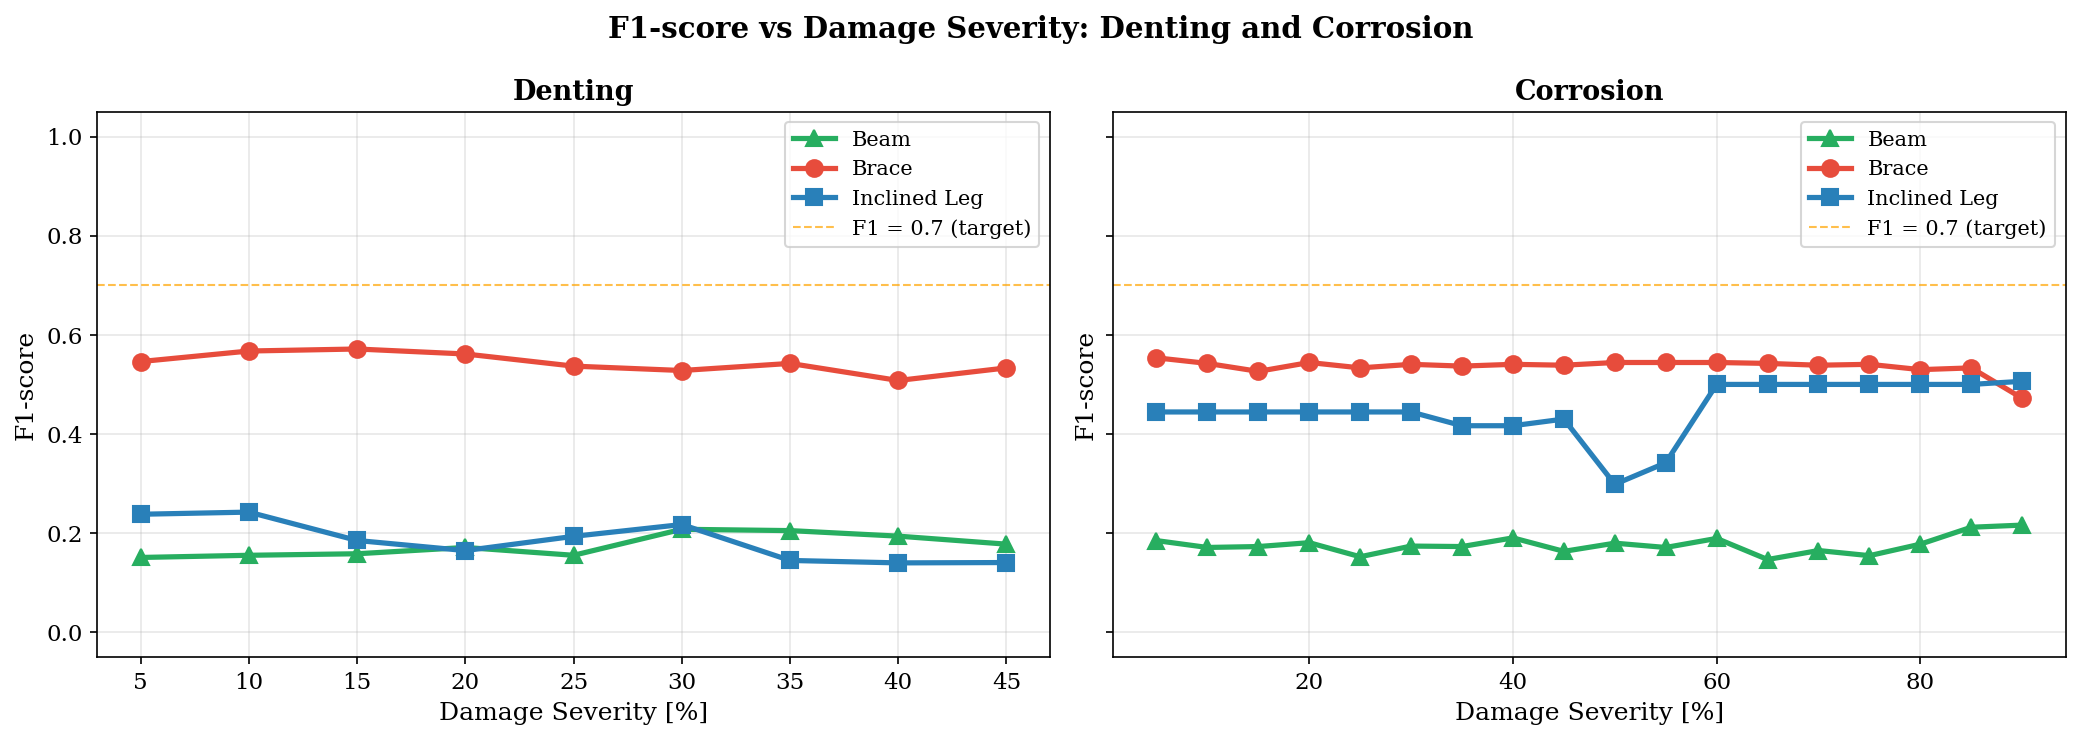

✓ Guardado: /home/fcisnerosr/github/Proyecto-doctoral/outputs/resultados_nuevos/F1_comparison_denting_corrosion.png


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
fig.suptitle('F1-score vs Damage Severity: Denting and Corrosion', 
             fontsize=14, fontweight='bold')

for ax, (tipo, tabla) in zip(axes, tablas.items()):
    cfg = paths[tipo]
    for elem in sorted(tabla['Tipo_elemento_a_buscar'].unique()):
        sub = tabla[tabla['Tipo_elemento_a_buscar'] == elem].sort_values('Porcentaje')
        ax.plot(
            sub['Porcentaje'], sub['F1_macro'],
            marker=ELEM_MARKERS.get(elem, 'o'),
            color=ELEM_COLORS.get(elem, 'gray'),
            linewidth=2.5, markersize=8,
            label=ELEM_LABELS.get(elem, elem)
        )
    ax.set_xlabel('Damage Severity [%]', fontsize=12)
    ax.set_ylabel('F1-score', fontsize=12)
    ax.set_title(f'{cfg["label_en"]}', fontsize=13, fontweight='bold')
    ax.set_ylim(-0.05, 1.05)
    ax.axhline(0.7, color='orange', linestyle='--', linewidth=1.0, alpha=0.7, label='F1 = 0.7 (target)')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
out_comparativo = resultados_nuevos / 'F1_comparison_denting_corrosion.png'
plt.savefig(out_comparativo, dpi=300)
plt.show()
print(f'✓ Guardado: {out_comparativo}')

## 7. Figura 3 — Curva ROC (TPR vs FPR) por tipo de elemento

El recorrido sobre severidades simula el comportamiento de un umbral: de 5% (punto más a la izquierda) a 45/90% (arriba a la derecha).

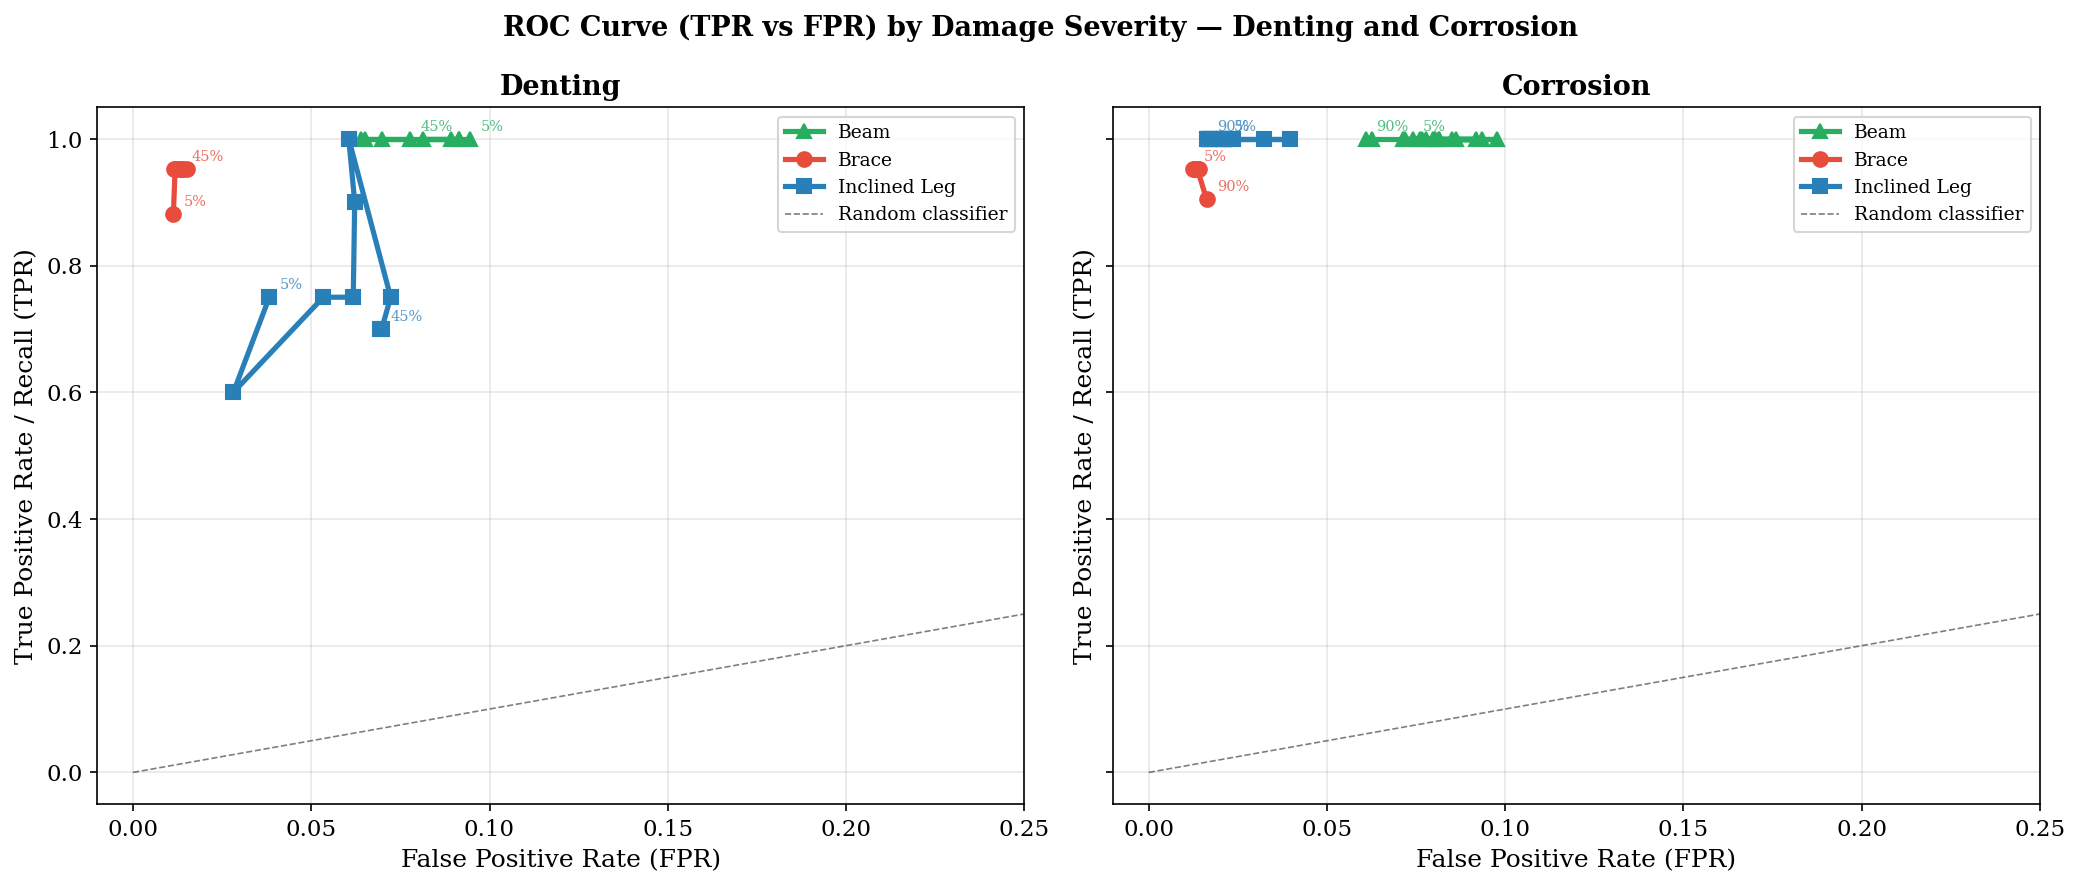

✓ Guardado: /home/fcisnerosr/github/Proyecto-doctoral/outputs/resultados_nuevos/ROC_curve_denting_corrosion.png


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True, sharex=True)
fig.suptitle('ROC Curve (TPR vs FPR) by Damage Severity — Denting and Corrosion',
             fontsize=13, fontweight='bold')

for ax, (tipo, tabla) in zip(axes, tablas.items()):
    cfg = paths[tipo]
    for elem in sorted(tabla['Tipo_elemento_a_buscar'].unique()):
        sub = tabla[tabla['Tipo_elemento_a_buscar'] == elem].sort_values('Porcentaje')
        ax.plot(
            sub['FPR_mean'], sub['Recall_macro'],
            marker=ELEM_MARKERS.get(elem, 'o'),
            color=ELEM_COLORS.get(elem, 'gray'),
            linewidth=2.5, markersize=7,
            label=ELEM_LABELS.get(elem, elem)
        )
        # Anotar el peor y mejor nivel de severidad
        for i, row in sub.iloc[[0, -1]].iterrows():
            ax.annotate(
                f"{int(row['Porcentaje'])}%",
                (row['FPR_mean'], row['Recall_macro']),
                textcoords='offset points', xytext=(5, 4),
                fontsize=7, color=ELEM_COLORS.get(elem, 'gray'), alpha=0.8
            )
    
    # Línea de azar
    ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8, alpha=0.5, label='Random classifier')
    ax.set_xlabel('False Positive Rate (FPR)', fontsize=12)
    ax.set_ylabel('True Positive Rate / Recall (TPR)', fontsize=12)
    ax.set_title(cfg['label_en'], fontsize=13, fontweight='bold')
    ax.set_xlim(-0.01, 0.25)
    ax.set_ylim(-0.05, 1.05)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
out_roc = resultados_nuevos / 'ROC_curve_denting_corrosion.png'
plt.savefig(out_roc, dpi=300)
plt.show()
print(f'✓ Guardado: {out_roc}')

## 8. Tabla Resumen Global (para paper)

Tabla consolidada de métricas por tipo de daño, tipo de elemento y umbrales clave de severidad.

In [9]:
resumen_global = []

for tipo in ['abolladura', 'corrosion']:
    tabla = tablas[tipo].copy()
    tabla['damage_type'] = paths[tipo]['label_en']
    resumen_global.append(tabla)

df_global = pd.concat(resumen_global, ignore_index=True)

# Tabla pivot: para cada tipo_daño × tipo_elemento → métricas en severidad @30% y @max
print('\n=== MÉTRICAS GLOBALES POR TIPO DE DAÑO Y ELEMENTO ===')
pivot = df_global.groupby(['damage_type', 'Tipo_elemento_a_buscar']).agg(
    Precision_avg=('Precision_macro', 'mean'),
    Recall_avg=('Recall_macro', 'mean'),
    F1_avg=('F1_macro', 'mean'),
    F1_max=('F1_macro', 'max'),
    FPR_avg=('FPR_mean', 'mean'),
).round(3)
print(pivot.to_string())

# Severidades donde F1 >= 0.7 por primera vez
print('\n=== UMBRAL DE DETECCIÓN CONFIABLE (F1 >= 0.7) ===')
for tipo in ['abolladura', 'corrosion']:
    label = paths[tipo]['label_en']
    for elem in sorted(tablas[tipo]['Tipo_elemento_a_buscar'].unique()):
        sub = tablas[tipo][tablas[tipo]['Tipo_elemento_a_buscar'] == elem].sort_values('Porcentaje')
        f1_07 = sub[sub['F1_macro'] >= 0.7]['Porcentaje'].min()
        print(f'  {label:10s} | {ELEM_LABELS.get(elem, elem):14s} | F1 ≥ 0.7 desde: {f1_07}%')


=== MÉTRICAS GLOBALES POR TIPO DE DAÑO Y ELEMENTO ===
                                    Precision_avg  Recall_avg  F1_avg  F1_max  FPR_avg
damage_type Tipo_elemento_a_buscar                                                    
Corrosion   Beam                            0.097       1.000   0.176   0.216    0.079
            Brace                           0.373       0.950   0.536   0.554    0.013
            Inclined_leg                    0.291       1.000   0.449   0.506    0.021
Denting     Beam                            0.096       1.000   0.175   0.208    0.081
            Brace                           0.382       0.944   0.544   0.571    0.013
            Inclined_leg                    0.106       0.767   0.185   0.242    0.057

=== UMBRAL DE DETECCIÓN CONFIABLE (F1 >= 0.7) ===
  Denting    | Beam           | F1 ≥ 0.7 desde: nan%
  Denting    | Brace          | F1 ≥ 0.7 desde: nan%
  Denting    | Inclined Leg   | F1 ≥ 0.7 desde: nan%
  Corrosion  | Beam           | F1 ≥ 0.

## 9. Exportar Tabla LaTeX para `main.tex`

Tabla lista para `\input{tablas/tabla_metricas_clasificacion.tex}` en la sección de Resultados.

In [ ]:
# Crear carpeta de tablas si no existe
tablas_dir = base_path / 'manuscript_AOR' / 'tablas'
tablas_dir.mkdir(parents=True, exist_ok=True)

# Construir tabla LaTeX completa (todos los niveles de severidad)
latex_rows = []
for tipo in ['abolladura', 'corrosion']:
    label = paths[tipo]['label_en']
    for elem in ['Brace', 'Inclined_leg', 'Beam']:
        sub = tablas[tipo][tablas[tipo]['Tipo_elemento_a_buscar'] == elem].sort_values('Porcentaje')
        if sub.empty:
            continue
        elem_label = ELEM_LABELS.get(elem, elem)
        for _, row in sub.iterrows():
            latex_rows.append({
                'Damage Type': label,
                'Element Type': elem_label,
                'Severity [\\%]': int(row['Porcentaje']),
                'TP': int(row['TP_sum']),
                'FP': int(row['FP_sum']),
                'FN': int(row['FN_sum']),
                'Precision': f"{row['Precision_macro']:.3f}",
                'Recall': f"{row['Recall_macro']:.3f}",
                'F1-score': f"{row['F1_macro']:.3f}",
            })

df_latex = pd.DataFrame(latex_rows)

# Generar código LaTeX
def df_to_latex_booktabs(df, caption, label):
    n_cols = len(df.columns)
    elem_col = df.columns[1]  # second column name (varies: 'Element Type' or 'Element')
    col_fmt = 'l' * 2 + 'r' * (n_cols - 2)

    lines = []
    lines.append(r'\begin{table}[htbp]')
    lines.append(r'  \centering')
    lines.append(r'  \caption{' + caption + r'}')
    lines.append(r'  \label{' + label + r'}')
    lines.append(r'  \small')
    lines.append(r'  \begin{tabular}{' + col_fmt + r'}')
    lines.append(r'    \toprule')

    # Header
    header = ' & '.join(df.columns) + r' \\'
    lines.append(f'    {header}')
    lines.append(r'    \midrule')

    # Rows con \midrule entre tipos de daño
    prev_damage = None
    prev_elem = None
    for _, row in df.iterrows():
        cur_damage = row['Damage Type']
        cur_elem = row[elem_col]

        if prev_damage is not None and cur_damage != prev_damage:
            lines.append(r'    \midrule')
        elif prev_elem is not None and cur_elem != prev_elem and cur_damage == prev_damage:
            lines.append(r'    \cmidrule{2-' + str(n_cols) + r'}')

        row_str = ' & '.join(str(v) for v in row.values) + r' \\'
        lines.append(f'    {row_str}')
        prev_damage = cur_damage
        prev_elem = cur_elem

    lines.append(r'    \bottomrule')
    lines.append(r'  \end{tabular}')
    lines.append(r'\end{table}')

    return '\n'.join(lines)


caption = (
    r'Classification metrics of the ICD+GA damage detection system. '
    r'Precision, Recall, and F1-score are computed as macro-averages '
    r'over all runs at each severity level. '
    r'TP: True Positives; FP: False Positives; FN: False Negatives.'
)

latex_code = df_to_latex_booktabs(df_latex, caption, 'tab:metricas_clasificacion')

out_tex = tablas_dir / 'tabla_metricas_clasificacion.tex'
out_tex.write_text(latex_code, encoding='utf-8')
print(f'✓ Tabla LaTeX guardada: {out_tex}')
print()
print('Primeras líneas del .tex:')
print('\n'.join(latex_code.split('\n')[:20]))


✓ Tabla LaTeX guardada: /home/fcisnerosr/github/Proyecto-doctoral/manuscript_AOR/tablas/tabla_metricas_clasificacion.tex

Primeras líneas del .tex:
\begin{table}[htbp]
  \centering
  \caption{Classification metrics of the ICD+GA damage detection system. Precision, Recall, and F1-score are computed as macro-averages over all runs at each severity level. TP: True Positives; FP: False Positives; FN: False Negatives.}
  \label{tab:metricas_clasificacion}
  \small
  \begin{tabular}{llrrrrrrr}
    \toprule
    Damage Type & Element Type & Severity [\%] & TP & FP & FN & Precision & Recall & F1-score \\
    \midrule
    Denting & Brace & 5 & 74 & 113 & 10 & 0.396 & 0.881 & 0.546 \\
    Denting & Brace & 10 & 80 & 118 & 4 & 0.404 & 0.952 & 0.567 \\
    Denting & Brace & 15 & 80 & 116 & 4 & 0.408 & 0.952 & 0.571 \\
    Denting & Brace & 20 & 80 & 121 & 4 & 0.398 & 0.952 & 0.561 \\
    Denting & Brace & 25 & 80 & 134 & 4 & 0.374 & 0.952 & 0.537 \\
    Denting & Brace & 30 & 80 & 139 & 4 & 0.365 &

## 10. Exportar Tabla Compacta para AOR (solo niveles clave)

Versión condensada: severidades 10%, 20%, 30% para abolladura y 20%, 40%, 60%, 80% para corrosión.

In [11]:
# Tabla compacta: solo niveles representativos
niveles_clave = {
    'abolladura': [10, 20, 30, 45],
    'corrosion':  [20, 40, 60, 90],
}

compact_rows = []
for tipo in ['abolladura', 'corrosion']:
    label = paths[tipo]['label_en']
    niveles = niveles_clave[tipo]
    for elem in ['Brace', 'Inclined_leg', 'Beam']:
        sub = tablas[tipo][
            (tablas[tipo]['Tipo_elemento_a_buscar'] == elem) &
            (tablas[tipo]['Porcentaje'].isin(niveles))
        ].sort_values('Porcentaje')
        for _, row in sub.iterrows():
            compact_rows.append({
                'Damage Type': label,
                'Element': ELEM_LABELS.get(elem, elem),
                'Severity': f"{int(row['Porcentaje'])}\\%",
                'Precision': f"{row['Precision_macro']:.3f}",
                'Recall': f"{row['Recall_macro']:.3f}",
                'F1': f"{row['F1_macro']:.3f}",
                'Avg FP': f"{row['FP_sum']/row['N_corridas']:.1f}",
            })

df_compact = pd.DataFrame(compact_rows)

caption_compact = (
    r'Summary of classification performance at key severity levels. '
    r'Avg~FP: average number of false alarms per run.'
)
latex_compact = df_to_latex_booktabs(df_compact, caption_compact, 'tab:metricas_compacta')

out_compact = tablas_dir / 'tabla_metricas_compacta.tex'
out_compact.write_text(latex_compact, encoding='utf-8')
print(f'✓ Tabla compacta guardada: {out_compact}')
print()
print(df_compact.to_string(index=False))

KeyError: 'Element Type'

## 11. Exportar Excel con todas las métricas

In [ ]:
# Guardar resultados detallados por corrida
for tipo in ['abolladura', 'corrosion']:
    out_xlsx = paths[tipo]['out_dir'] / f'metricas_clasificacion_{tipo}.xlsx'
    with pd.ExcelWriter(out_xlsx, engine='openpyxl') as writer:
        # Hoja 1: métricas por corrida
        cols_corrida = ['ID', 'Elemento', 'Porcentaje', 'Tipo_elemento_a_buscar',
                        'DeteccionOK', 'DeteccionOK_binario', 'N_FalsosPositivos',
                        'ICD', 'TP', 'FP', 'FN', 'TN', 'Precision', 'Recall', 'F1', 'FPR']
        dfs_metricas[tipo][cols_corrida].to_excel(writer, sheet_name='Por_Corrida', index=False)
        
        # Hoja 2: métricas agregadas
        tablas[tipo].to_excel(writer, sheet_name='Por_Severidad_Elemento', index=False)
        
        # Hoja 3: tabla compacta
        df_compact[df_compact['Damage Type'] == paths[tipo]['label_en']].to_excel(
            writer, sheet_name='Tabla_Compacta_Paper', index=False)
    
    print(f'✓ Excel guardado: {out_xlsx.name}')

print()
print('=== RESUMEN FINAL ===')
print('Archivos generados:')
print('  abolladuras_2026/precision_recall_F1_Denting.png')
print('  corrosion_2026/precision_recall_F1_Corrosion.png')
print('  resultados_nuevos/F1_comparison_denting_corrosion.png')
print('  resultados_nuevos/ROC_curve_denting_corrosion.png')
print('  manuscript_AOR/tablas/tabla_metricas_clasificacion.tex')
print('  manuscript_AOR/tablas/tabla_metricas_compacta.tex')
print('  abolladuras_2026/metricas_clasificacion_abolladura.xlsx')
print('  corrosion_2026/metricas_clasificacion_corrosion.xlsx')
print()
print('✅ PUNTO 5 COMPLETADO — listo para integrar en main.tex')